In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Dimensionality Reduction
In the process of training models we feature engineering find some datasets with a lot of features.most of these features would not contribute signitificaly to predictions,making the training process slow.

In [2]:
from sklearn.datasets import load_wine

data = load_wine()
x = data.data
y = data.target


Obtain 2 principals components of dataset:

In [3]:
x_centered = x - x.mean(axis=0)
u,s,vt = np.linalg.svd(x_centered)
comp1 = vt.T[:,0]
comp2 = vt.T[:,1]

print(comp1,comp2)

[-1.65926472e-03  6.81015556e-04 -1.94905742e-04  4.67130058e-03
 -1.78680075e-02 -9.89829680e-04 -1.56728830e-03  1.23086662e-04
 -6.00607792e-04 -2.32714319e-03 -1.71380037e-04 -7.04931645e-04
 -9.99822937e-01] [-1.20340617e-03 -2.15498184e-03 -4.59369254e-03 -2.64503930e-02
 -9.99344186e-01 -8.77962152e-04  5.18507284e-05  1.35447892e-03
 -5.00440040e-03 -1.51003530e-02  7.62673115e-04  3.49536431e-03
  1.77738095e-02]


contrary: projecting a data in a hyperplane of other components

In [ ]:
#3 components:
w3 = vt.T[:,:3] # 3d hyperplane

x3d = x_centered.dot(w3)
print(x3d) # --> 3d vectors 

In [ ]:
#using sklearn:
from sklearn.decomposition import PCA

pca = PCA(n_components=4)
x4d = pca.fit_transform(x)
print(x4d) # --> 4d project

we can see the influence of variance for each component using explained variance ratio:

In [6]:
pca.explained_variance_ratio_

array([9.98091230e-01, 1.73591562e-03, 9.49589576e-05, 5.02173562e-05])

Using it,you can measure the number of dimensions to preserve to keep a determined variance:

In [7]:
var = np.cumsum(pca.explained_variance_ratio_) #sum ele in axis array
dim = np.argmax(var >= 0.90) + 1

#you could put this limit of variance when selecting the components:

pca2 = PCA(n_components=0.95)
pca3 = PCA(n_components=dim)

plot the n dim x variance:

[]

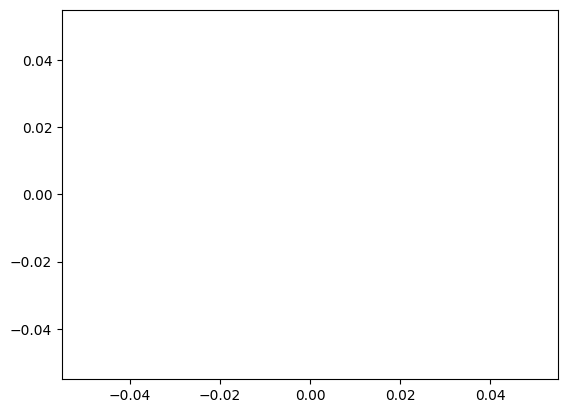

In [8]:
plt.plot()

Inverse transform helps when you want to reset a projection to its original dimension:

In [9]:
x_90p = pca2.fit_transform(x)
x_100P = pca2.inverse_transform(x_90p)

pca solver: svd-randomizer: less computaion to find n k components

### Incremental Pca:
As Pca uses the whole trainig set,it becomes hard to train new data.

The incremnetal pca (IPCA) has developed for help us in that cases.this divide the data in batchs like stochastic models and is good for online training.

In [ ]:
from sklearn.decomposition import IncrementalPCA

n_batchs = 400
ipca = IncrementalPCA(n_components=3)

for x_batch in np.array_split(x,n_batchs):
    ipca.partial_fit(x) # online training 

#projecting after find patterns:
ipca.fit_transform(x)

As in Suport Vector Machines,we also have Kernel model of Pca.this model allows us compute projections in complex dimensional spaces:

In [ ]:
from sklearn.decomposition import KernelPCA

k_pca = KernelPCA(n_components=2,kernel='rbf')


We could save a the original dimension saving a pre-image of data,allowing the reconstruction of a space:

In [13]:

k_pca = KernelPCA(n_components=2,kernel='rbf',fit_inverse_transform=True)
#-->save the dim of data training 

x_reduced = k_pca.fit_transform(x)
x_original_dim = k_pca.inverse_transform(x_reduced)

from sklearn.metrics import mean_squared_error


and you can evaluate how well the model project:

In [14]:
print(mean_squared_error(x,x_original_dim))

7545.882584490346


### Locally Linear Embedding
Instead of projections,lle meansure the relation between training set neighborns and search for a low dimension which keep the aproaching relation.